### Simulation Results

In [1]:
import numpy as np, pandas as pd
import importlib
import test_WTM as wtm
import gudhi_persistence as gp
import utilsA1 as utils
import os, matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from lifelines import CoxTimeVaryingFitter


In [7]:
importlib.reload(wtm)
importlib.reload(utils)
importlib.reload(gp)

PATH = os.getcwd()
output_file = "FLCRM"
params_temp_list = {'num_nodes': 50, 'num_neighbor_nodes': 1,
                    'total_random_edges': 2, 'distance_threshold': 20, 'weighted': False,
                    'ngeo_placement': 'ngeo_per_node', 'n_seeds': 2, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'all_combinations', 'calculate_representation': True,
                    'bandwidth': 0.1, 'num_landscapes': 3, 'resolution': 50}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 200

df, activation_results = wtm.main_sims(params_list=[params_temp_list],
                   output_file=output_file, save_files=False)

Pre cleaning: [0. 0. 1. 2. 3. 4. 4. 3. 4. 4. 5. 5. 4. 4. 3. 3. 4. 5. 4. 3. 2. 2. 1. 1.
 1. 1. 2. 3. 2. 2. 3. 3. 4. 5. 4. 5. 5. 6. 5. 5. 4. 3. 2. 2. 2. 3. 3. 2.
 2. 1.]
Post cleaning [0 0 1 2 3 4 4 3 4 4 5 5 4 4 3 3 4 5 4 3 2 2 1 1 1 1 2 3 2 2 3 3 4 5 4 5 5
 6 5 5 4 3 2 2 2 3 3 2 2 1]
Pre cleaning: [0. 1. 0. 1. 2. 3. 3. 2. 3. 3. 4. 5. 4. 5. 4. 3. 4. 5. 4. 3. 2. 2. 1. 2.
 2. 1. 1. 2. 1. 2. 2. 2. 3. 4. 3. 4. 5. 5. 4. 5. 4. 3. 2. 3. 3. 3. 3. 2.
 2. 1.]
Post cleaning [0 1 0 1 2 3 3 2 3 3 4 5 4 5 4 3 4 5 4 3 2 2 1 2 2 1 1 2 1 2 2 2 3 4 3 4 5
 5 4 5 4 3 2 3 3 3 3 2 2 1]
Pre cleaning: [0. 1. 1. 0. 1. 2. 3. 3. 2. 2. 3. 4. 4. 5. 4. 3. 4. 4. 4. 3. 2. 2. 1. 2.
 2. 1. 2. 3. 2. 2. 1. 1. 2. 3. 4. 5. 5. 4. 3. 4. 4. 3. 2. 3. 3. 3. 3. 2.
 2. 1.]
Post cleaning [0 1 1 0 1 2 3 3 2 2 3 4 4 5 4 3 4 4 4 3 2 2 1 2 2 1 2 3 2 2 1 1 2 3 4 5 5
 4 3 4 4 3 2 3 3 3 3 2 2 1]
Pre cleaning: [0. 1. 2. 1. 0. 1. 2. 3. 3. 3. 4. 5. 4. 5. 4. 3. 4. 5. 4. 3. 2. 2. 1. 2.
 2. 1. 1. 2. 2. 1. 2. 2. 2. 2. 3. 4. 5. 5. 4. 5. 4. 3. 2. 

In [69]:
df.head(10)

,simulation_id,realization_id,num_nodes,time,state,state_abnormal_sum,num_active_nodes,active_nodes,node_active_threshold,H0,...,distance_threshold,L_0,L_1,L_2,I_0,I_1,I_2,E_0,E_1,E_2
0,0,0,100,0,0,4750,1,"[0.0, nan, nan, nan, nan, nan, nan, nan, nan, ...",0.01,1,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
1,0,0,100,1,0,4750,6,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...",0.01,4,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[2.2145596077736833e-16, 2.168919038848509e-16...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",21,0,0
2,0,0,100,2,0,4750,24,"[0.0, 1.0, 2.0, nan, 2.0, nan, nan, nan, nan, ...",0.01,13,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0009514869169886112, 0.0018399126731116105,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",57,0,0
3,0,0,100,3,0,4750,70,"[0.0, 1.0, 2.0, 3.0, 2.0, 3.0, 3.0, 3.0, nan, ...",0.01,15,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[3.777027811185612e-08, 7.427004617966068e-08,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",63,0,0
4,0,0,100,4,1,4750,99,"[0.0, 1.0, 2.0, 3.0, 2.0, 3.0, 3.0, 3.0, 4.0, ...",0.01,1,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
5,0,0,100,5,1,4750,100,"[0.0, 1.0, 2.0, 3.0, 2.0, 3.0, 3.0, 3.0, 4.0, ...",0.01,1,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
6,0,1,100,0,0,4750,1,"[nan, 0.0, nan, nan, nan, nan, nan, nan, nan, ...",0.01,1,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
7,0,1,100,1,0,4750,6,"[1.0, 0.0, 1.0, nan, nan, nan, nan, nan, nan, ...",0.01,4,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[2.2145596077736833e-16, 2.168919038848509e-16...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",21,0,0
8,0,1,100,2,0,4750,23,"[1.0, 0.0, 1.0, 2.0, nan, nan, 2.0, nan, nan, ...",0.01,13,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0007136318899541624, 0.0013799668022959474,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",57,0,0
9,0,1,100,3,0,4750,65,"[1.0, 0.0, 1.0, 2.0, 3.0, 3.0, 2.0, 3.0, nan, ...",0.01,17,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0

#### Homology Representation

In [77]:

importlib.reload(gp)

importlib.reload(wtm)

params_temp_list['seeding_method'] = 'cluster_seeding'
params_temp_list['calculate_representation'] = bool(False)
G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
graph, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)

utils.visualize_step_animation_new(G=graph, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))
betti_numbers, persistence, persistence_intervals_for_diagram = gp.compute_persistence(graph=graph, activation_times=activation_times, max_dim=2)
print(f"Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/{output_file}.html")


Pre cleaning: [ 3.  2.  3.  4.  5.  4.  3.  2.  3.  4.  5.  6.  5.  5.  4.  3.  4.  3.
  2.  3.  4.  4.  3.  2.  1.  2.  3.  4.  5.  5.  6.  7.  8.  9. 10. 11.
 10.  9.  8.  7.  6.  5.  4.  3.  2.  1.  2.  3.  4.  4.  3.  4.  5.  6.
  7.  8.  8.  7.  6.  5.  6.  6.  5.  4.  5.  6.  5.  4.  3.  2.  1.  0.
  1.  0.  1.  2.  3.  4.  5.  6.  5.  6.  7.  6.  5.  4.  4.  5.  6.  5.
  4.  5.  6.  7.  8.  8.  7.  6.  5.  4.]
Post cleaning [3 2 3 4 5 4 3 2 3 4 5 6 5 5 4 3 4 3 2 3 4 4 3 2 1 2 3 4 5 5 6 7 8 9 10 11
 10 9 8 7 6 5 4 3 2 1 2 3 4 4 3 4 5 6 7 8 8 7 6 5 6 6 5 4 5 6 5 4 3 2 1 0
 1 0 1 2 3 4 5 6 5 6 7 6 5 4 4 5 6 5 4 5 6 7 8 8 7 6 5 4]
Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/FLCRM.html


In [78]:
persistence_intervals_for_diagram

[(1, (11.0, inf)),
 (0, (0.0, inf)),
 (0, (1.0, 8.0)),
 (0, (1.0, 8.0)),
 (0, (2.0, 6.0)),
 (0, (2.0, 5.0)),
 (0, (4.0, 7.0)),
 (0, (2.0, 4.0)),
 (0, (4.0, 6.0)),
 (0, (4.0, 6.0)),
 (0, (0.0, 1.0)),
 (0, (3.0, 4.0)),
 (0, (3.0, 4.0)),
 (0, (5.0, 6.0)),
 (0, (5.0, 6.0))]

In [79]:
persistence

array([[list([(0.0, inf), (0.0, inf)]), list([]), list([])],
       [list([(1.0, inf), (1.0, inf), (0.0, inf), (0.0, 1.0)]), list([]),
        list([])],
       [list([(2.0, inf), (2.0, inf), (2.0, inf), (0.0, inf), (1.0, inf), (1.0, inf), (0.0, 1.0)]),
        list([]), list([])],
       [list([(3.0, inf), (3.0, inf), (0.0, inf), (2.0, inf), (1.0, inf), (2.0, inf), (1.0, inf), (2.0, inf), (0.0, 1.0)]),
        list([]), list([])],
       [list([(4.0, inf), (4.0, inf), (4.0, inf), (0.0, inf), (2.0, inf), (1.0, inf), (2.0, inf), (1.0, inf), (2.0, 4.0), (0.0, 1.0), (3.0, 4.0), (3.0, 4.0)]),
        list([]), list([])],
       [list([(4.0, inf), (5.0, inf), (5.0, inf), (4.0, inf), (0.0, inf), (1.0, inf), (2.0, inf), (1.0, inf), (4.0, inf), (2.0, 5.0), (2.0, 4.0), (0.0, 1.0), (3.0, 4.0), (3.0, 4.0)]),
        list([]), list([])],
       [list([(4.0, inf), (1.0, inf), (1.0, inf), (0.0, inf), (2.0, 6.0), (2.0, 5.0), (2.0, 4.0), (4.0, 6.0), (4.0, 6.0), (0.0, 1.0), (3.0, 4.0), (3.0, 4.0), (5.0

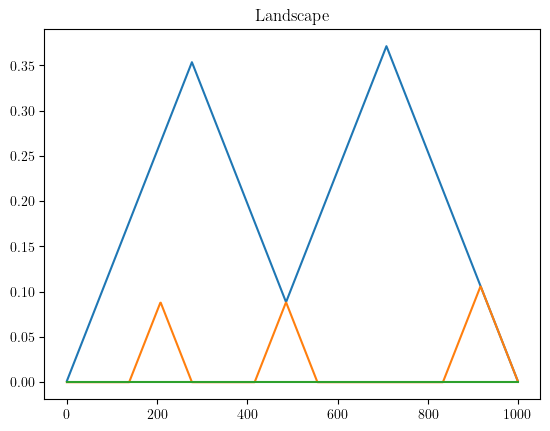

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import MinMaxScaler

from gudhi.representations import (DiagramSelector, Clamping, Landscape, Silhouette, BettiCurve, ComplexPolynomial,\
  TopologicalVector, DiagramScaler, BirthPersistenceTransform,\
  PersistenceImage, PersistenceWeightedGaussianKernel, Entropy, \
  PersistenceScaleSpaceKernel, SlicedWassersteinDistance,\
  SlicedWassersteinKernel, PersistenceFisherKernel, WassersteinDistance)

D1 = np.array([[0.,4.],[1.,2.],[3.,8.],[6.,8.], [0., np.inf], [5., np.inf]])

proc1 = DiagramSelector(use=True, point_type="finite")
proc2 = DiagramScaler(use=True, scalers=[([0,1], MinMaxScaler())])
proc3 = DiagramScaler(use=True, scalers=[([1], Clamping(maximum=.9))])
D1 = proc3(proc2(proc1(D1)))
#
# plt.scatter(D1[:,0], D1[:,1])
# plt.plot([0.,1.],[0.,1.])
# plt.title("Test Persistence Diagram for vector methods")
# plt.show()

LS = Landscape(resolution=1000)
L = LS(D1)
plt.plot(L[:1000])
plt.plot(L[1000:2000])
plt.plot(L[2000:3000])
plt.title("Landscape")
plt.show()

In [86]:
importlib.reload(gp)
# test_pers_0 = np.array([(birth, death) for dim, intervla in persistence if dim == 0])
L, I, E, params = gp.persistence_representation_t(persistence, num_landscapes=4)

# landscape
# plt.plot(df.loc[row_id, 'L_0'][:resolution])
# plt.plot(df.loc[row_id, 'L_1'][resolution: resolution*2])
# plt.plot(df.loc[row_id, 'L_2'][resolution*2:resolution*3])
# plt.title("Landscape")
# plt.show()

{0: array([0.02495671, 0.04991342, 0.07487013, 0.09982684, 0.12478355,
        0.14974026, 0.17469697, 0.19965368, 0.22461039, 0.2495671 ,
        0.27452381, 0.29948052, 0.32443723, 0.34939394, 0.37435065,
        0.39930736, 0.42426407, 0.44922078, 0.47417749, 0.4991342 ,
        0.52409091, 0.54904762, 0.57400433, 0.59896104, 0.62391775,
        0.62391775, 0.59896104, 0.57400433, 0.54904762, 0.52409091,
        0.4991342 , 0.47417749, 0.44922078, 0.42426407, 0.39930736,
        0.37435065, 0.34939394, 0.32443723, 0.29948052, 0.27452381,
        0.2495671 , 0.22461039, 0.19965368, 0.17469697, 0.14974026,
        0.12478355, 0.09982684, 0.07487013, 0.04991342, 0.02495671,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0

In [89]:
type(L[0][0])

list

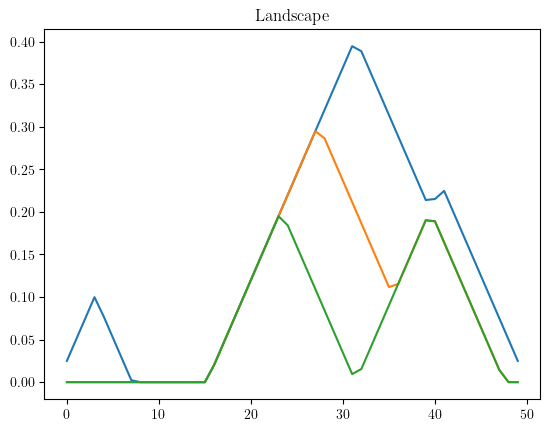

In [99]:
resolution = params['resolution']
timestep = 7
test_resolution = 10
plt.plot(L[timestep][0][:resolution])
plt.plot(L[timestep][0][resolution: resolution*2])
plt.plot(L[timestep][0][resolution*2: resolution*3])
# plt.plot(L[0][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

In [41]:
gp.betti_nums_over_time(betti_over_time=betti_numbers)

SyntaxError: invalid syntax (2012522241.py, line 1)

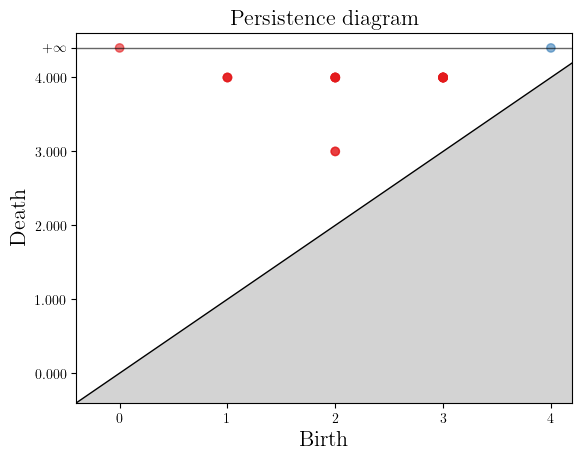

In [23]:
gp.persistence_diagram(persistence_intervals_for_diagram)

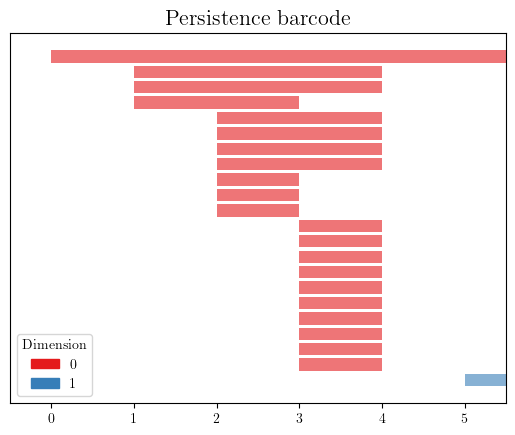

In [31]:

gp.persistence_barcodes(persistence_intervals_for_diagram)

#### Persistence Images / Landscapes

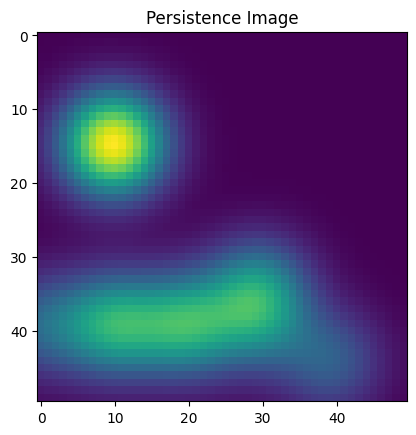

In [25]:
row_id = 12
resolution = params_temp_list['resolution']
plt.imshow(np.flip(np.reshape(df.loc[row_id, 'I_0'], [resolution,resolution]), 0))
plt.title("Persistence Image")
plt.show()

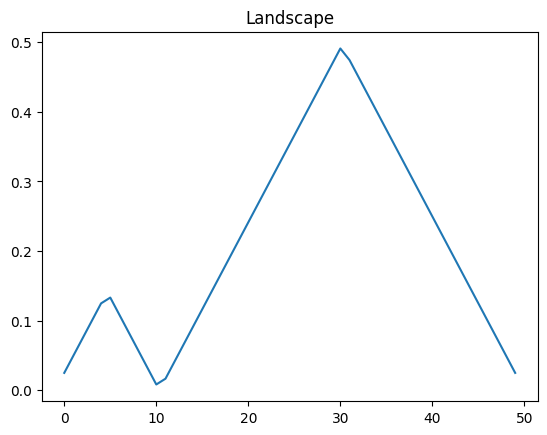

In [26]:
plt.plot(df.loc[row_id, 'L_0'][:resolution])
plt.plot(df.loc[row_id, 'L_1'][resolution: resolution*2])
plt.plot(df.loc[row_id, 'L_2'][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

In [27]:
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 5

df_pca = df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2'], how='left')


In [28]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Explained variance ratio: [0.44755229 0.6298431  0.75701376 0.83084355 0.88180965]
Skipping L_1 — no valid data.
Skipping L_2 — no valid data.
Explained variance ratio: [0.38793786 0.5829977  0.70774698 0.79391232 0.85311847]
Skipping I_1 — no valid data.
Skipping I_2 — no valid data.


In [29]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["simulation_id", "realization_id", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["simulation_id", "realization_id"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])


ordered_cols = ["id", "start", "stop", "state"] + landscape_cols + image_cols + essentials_cols
df_pca['id'] = df['simulation_id'].astype(str) + df['realization_id'].astype(str) + df['time'].astype(str)

df_pca = df_pca[ordered_cols]
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_22172\2291923608.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,L_0_PC1,L_0_PC2,L_0_PC3,L_0_PC4,L_0_PC5,I_0_PC1,I_0_PC2,I_0_PC3,I_0_PC4,I_0_PC5,E_0,E_1,E_2
0,000,0,1.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
1,001,1,2.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
2,002,2,3.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
3,003,3,4.0,0,1.227786,-0.209446,-1.123932,-0.616485,-0.195752,129.463900,28.349948,-35.086232,-1.983025,-8.745611,6,0,0
4,004,4,5.0,0,-0.990994,-1.300032,-0.446695,0.316252,-0.088538,-10.062214,-97.581546,36.969592,-62.342295,-16.904295,7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6785,012241,1,2.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
6786,012242,2,3.0,0,-0.899967,0.673334,-0.229784,0.239591,-0.176090,76.627901,-38.781903,-40.092621,-17.176746,4.723292,6,0,0
6787,012243,3,4.0,0,0.078192,0.266495,-0.525209,0.329128,0.723523,38.500484,-17.358051,72.646504,-26.260030,3.410798,9,0,0
6788,012244,4,5.0,1,-0.455789,-0.621308,0.214957,0.070888,-0.106115,-52.160641,-69.832901,9.217277,37.328155,7.161412,11,0,0


### Time-Varying FLCRM

In [30]:
df_pca.drop(columns = ['E_1', 'E_2'], inplace=True)

ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 6790 periods, 6790 subjects, 2364 events>
         event col = 'state'
number of subjects = 6790
 number of periods = 6790
  number of events = 2364
partial log-likelihood = -14294.08
  time fit was run = 2025-08-19 00:20:46 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
L_0_PC1    0.74      2.11      0.10            0.55            0.94                1.74                2.55
L_0_PC2   -0.00      1.00      0.07           -0.14            0.13                0.87                1.14
L_0_PC3    0.08      1.09      0.08           -0.07            0.24                0.93                1.27
L_0_PC4    0.30      1.36      0.09            0.13            0.48                1.14                1.62
L_0_PC5    0.34      1.41      0.10            0.16            0.53                1.17                1.70
I_0_PC1   -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
I_0_PC2   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
I_0_PC3   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
I_0_PC4    0.01      1.01      0.00            0.00            0.01                1.00                1.01
I_0_PC5    0.00      1.00      0.00            0.00            0.01                1.00                1.01
E_0       -0.05      0.95      0.02           -0.09           -0.00                0.91                1.00

           cmp to     z      p  -log2(p)
covariate                               
L_0_PC1      0.00  7.65 <0.005     45.48
L_0_PC2      0.00 -0.01   0.99      0.02
L_0_PC3      0.00  1.03   0.30      1.72
L_0_PC4      0.00  3.40 <0.005     10.56
L_0_PC5      0.00  3.60 <0.005     11.59
I_0_PC1      0.00 -5.90 <0.005     28.00
I_0_PC2      0.00 -1.35   0.18      2.49
I_0_PC3      0.00 -2.95 <0.005      8.31
I_0_PC4      0.00  6.32 <0.005     31.86
I_0_PC5      0.00  4.73 <0.005     18.73
E_0          0.00 -2.17   0.03      5.07
---
Partial AIC = 28610.16
log-likelihood ratio test = 388.19 on 11 df
-log2(p) of ll-ratio test = 251.49

<Axes: xlabel='log(HR) (95% CI)'>

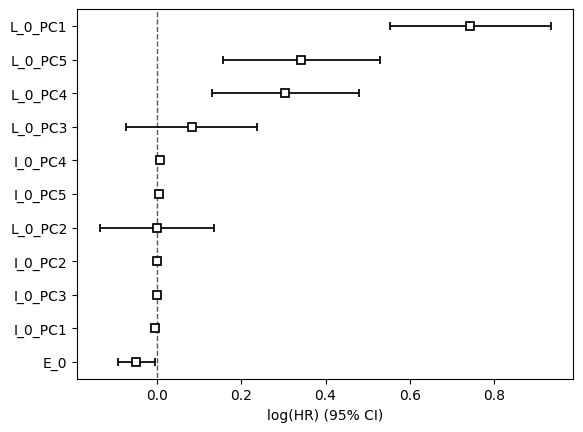

In [31]:
ctv.plot()
